In [80]:
#Imports numpy for math, matplotlib for visualizations, noiseProjectBase for base numerical methods and sampling.
import numpy as np
import matplotlib.pyplot as plt
import noiseProjectBase as npb

In [81]:
#Generates correlated Bz noise using an AR(1) process with timescale of tau for the correlation.
#Inputs: B0 is the constant average magnetic field, sigma is the standard deviation, tau is the correlation time, 
#numTrials is the number of trials, deltat is the timestep, and tmax is the total time of the evolution.
#Output: Array with all correlated Bz trajectories.
def generateCorrelatedBzData(B0, sigma, tau, numTrials, deltat, tmax):
    x = np.exp(-deltat/tau)
    BzData = []
    for i in range(numTrials):
        noise = np.random.normal(0.0, sigma)
        BzList = [B0+noise]
        for j in range(int(tmax/deltat)):
            random = np.random.normal(0.0, 1.0)

            #Updates noise so every value depends partly on the immediate value before it and a new random value.
            noise = x*noise+sigma*np.sqrt(1-x*x)*random
            BzList.append(B0+noise)
        BzData.append(BzList)
    return np.array(BzData)

In [82]:
#Calculates the analytical average expectation value of the x-component of the spin for correlated Lorentzian noise.
#Inputs: Initial amplitudes, constant magnetic field B0, noise strength sigma, correlation time tau, and timeList with all time values.
#Output: Analytical X expectation value at each time.
def expectedAverageXCorrelated(alpha0, beta0, B0, sigma, tau, timeList):
    expectedXList = []
    for time in timeList:

        #Calculates the variance of the random accumulated phase.
        phaseVariance = 2*sigma*sigma*(tau*time-tau*tau*(1-np.exp(-time/tau)))

        #Combines precession from B0 with dephasing from the noise.
        expectedX = np.real(alpha0.conjugate()*beta0*np.exp(2*1.0j*B0*time))*2*np.exp(-2*phaseVariance)
        expectedXList.append(expectedX)
    return expectedXList

In [83]:
#Calculates the numerical correlation function based on the generated Bz noise trajectories.
#Inputs: BzData contains the trajectories of Bz, B0 is the constant field, deltat is the timestep, stepTime is the time separation for the correlation function.
#Outputs: Time separation list and their correlation values.
def numericalNoiseCorrelation(BzData, B0, deltat, stepTime):

    #Subtracts the constant field so only the noisy δB remains.
    dBzData = BzData-B0
    stepsTimeList = []
    numericalCorrelationList = []

    #Compares each noise trajectory with a time-shifted version of itself.
    #Compares every noise trajectory with a version of itself separated by the time separation.
    for steps in range(int(stepTime/deltat)+1):
        if steps==0:
            products = dBzData*dBzData
        else:
            products = dBzData[:, :-steps]*dBzData[:, steps:]
        stepsTimeList.append(steps*deltat)
        numericalCorrelationList.append(np.mean(products))
    return np.array(stepsTimeList), np.array(numericalCorrelationList)

In [84]:
#Calculates the analytical exponential correlation function for the correlated noise model.
#Inputs: sigma is the noise standard deviation, tau is the correlation time, and stepsTimeList contains the time separations.
#Output: Analytical noise correlation at every time separation.
def analyticalNoiseCorrelation(sigma, tau, stepsTimeList):
    return sigma*sigma*np.exp(-stepsTimeList/tau)

In [85]:
#Calculates the analytical Lorentzian power spectral density of the correlated noise.
#Inputs: Sigma is the noise standard deviation, tau is the correlation time, maxOmega is the maximum angular frequency, and omegaStep is the frequency spacing.
#Outputs: Angular frequencies and their analytical PSD values.
def analyticalPSD(sigma, tau, maxOmega, omegaStep):
    omegaList = []
    PSDList = []
    omega = 0.0

    #Evaluates the analytical Lorentzian PSD over the chosen frequency range.
    while omega<=maxOmega:
        PSD = sigma*sigma*tau/(np.pi*(1+omega*omega*tau*tau))
        omegaList.append(omega)
        PSDList.append(PSD)
        omega = omega+omegaStep
    return np.array(omegaList), np.array(PSDList)

In [86]:
#Calculates the numerical PSD from the numerical correlation function using a cosine Fourier transform.
#Inputs: Correlation time values, numerical correlation values, maximum angular frequency, and spacing of the frequency.
#Outputs: Angular frequencies and their numerical PSD values.
def numericalPSD(stepsTimeList, numericalCorrelationList, maxOmega, omegaStep):
    omegaList = []
    numericalPSDList = []
    omega = 0.0

    #Numerically integrates the correlation function multiplied by cos(omega*t) for each frequency.
    while omega<=maxOmega:
        inIntegral = numericalCorrelationList*np.cos(omega*stepsTimeList)
        PSD = np.trapz(inIntegral, stepsTimeList)/np.pi
        omegaList.append(omega)
        numericalPSDList.append(PSD)
        omega = omega+omegaStep
    return np.array(omegaList), np.array(numericalPSDList)

In [87]:
#Initial state is an equal superposition, with no magnetic field components in the x or y directions.
alpha0 = 1/np.sqrt(2)
beta0 = 1/np.sqrt(2)
Bx = 0.0
By = 0.0

#Defines the constant average magnetic field, noise strength, correlation time, timestep, total evolution time, and number of noise trials.
B0 = 5.0
sigma = 0.5
tau = 0.3
deltat = 0.005
tmax = 10.0
numTrials = 10000

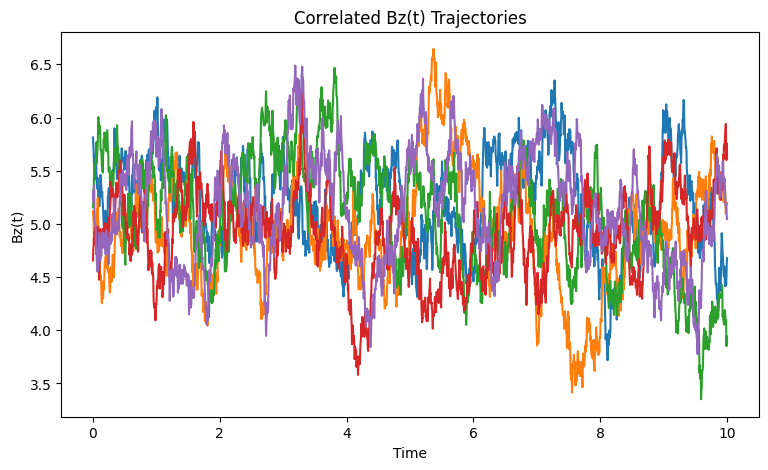

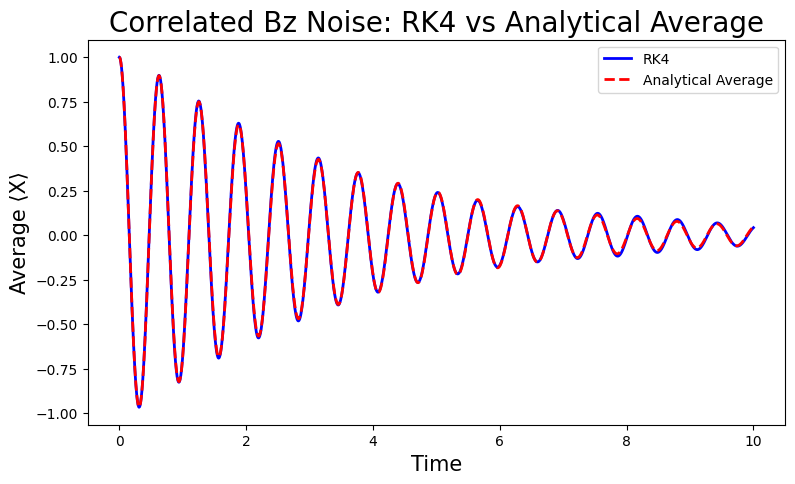

In [88]:
#Fixes the random seed and generates correlated magnetic-field trajectories.
np.random.seed(1)
BzDataCorrelated = generateCorrelatedBzData(B0, sigma, tau, numTrials, deltat, tmax)

#Calculates the ensemble-averaged spin evolution using the exact constant-field evolution at each timestep.
BzListCorrelated, newTimeListCorrelated, newAlphaListCorrelated, newBetaListCorrelated, newXListCorrelated, newNormListCorrelated = npb.Bzaverages(alpha0, beta0, Bx, By, BzDataCorrelated, deltat, tmax, 4)

#Plots five example correlated Bz trajectories.
plt.figure(figsize=(9, 5))
timeList = np.arange(len(BzDataCorrelated[0]))*deltat

for i in range(5):
    plt.plot(timeList, BzDataCorrelated[i])

plt.title("Correlated Bz(t) Trajectories")
plt.xlabel("Time")
plt.ylabel("Bz(t)")
plt.show()

#Calculates the same noisy spin evolution using RK4 and the exact constant-field evolution method.
BzListRK4Correlated, timeListRK4Correlated, alphaListRK4Correlated, betaListRK4Correlated, xListRK4Correlated, normListRK4Correlated = npb.Bzaverages(alpha0, beta0, Bx, By, BzDataCorrelated, deltat, tmax, 3)
BzListExactCorrelated, timeListExactCorrelated, alphaListExactCorrelated, betaListExactCorrelated, xListExactCorrelated, normListExactCorrelated = npb.Bzaverages(alpha0, beta0, Bx, By, BzDataCorrelated, deltat, tmax, 4)

#Calculates the analytical average X expectation value for comparison.
expectedXListCorrelated = expectedAverageXCorrelated(alpha0, beta0, B0, sigma, tau, timeListExactCorrelated)

#Compares the RK4 simulation with the analytical correlated-noise result.
plt.figure(figsize=(9, 5))
plt.plot(timeListRK4Correlated, xListRK4Correlated, label="RK4", color="blue", linewidth=2)
#plt.plot(timeListExactCorrelated, xListExactCorrelated, linestyle="--", label="Exact")
plt.plot(timeListExactCorrelated, expectedXListCorrelated, linestyle="--", label="Analytical Average", color="red", linewidth=2)
plt.title("Correlated Bz Noise: RK4 vs Analytical Average", fontsize=20)
plt.xlabel("Time", fontsize=15)
plt.ylabel("Average ⟨X⟩", fontsize=15)
plt.legend()
plt.show()

#Calculates the absolute difference between the RK4 simulation and analytical prediction.
xListRK4Correlated = np.array(xListRK4Correlated)
xListExactCorrelated = np.array(xListExactCorrelated)
rk4AnalyticalDifferenceCorrelated = np.abs(xListRK4Correlated-expectedXListCorrelated)

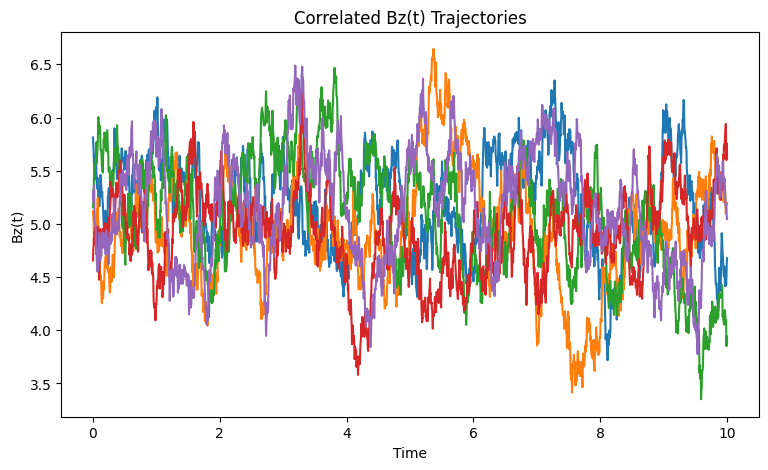

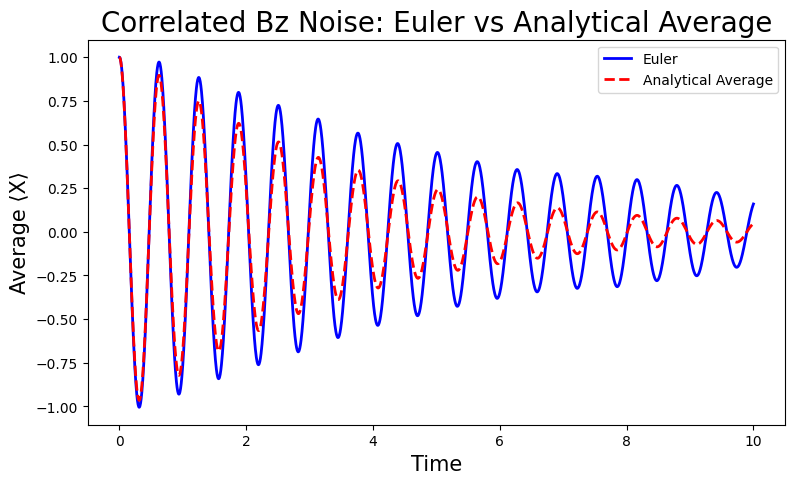

In [89]:
#Regenerates the same correlated noise trajectories using the same random seed.
np.random.seed(1)
BzDataCorrelated = generateCorrelatedBzData(B0, sigma, tau, numTrials, deltat, tmax)

#Calculates the ensemble-averaged spin evolution using the exact constant-field method.
BzListCorrelated, newTimeListCorrelated, newAlphaListCorrelated, newBetaListCorrelated, newXListCorrelated, newNormListCorrelated = npb.Bzaverages(alpha0, beta0, Bx, By, BzDataCorrelated, deltat, tmax, 4)

#Plots five example correlated Bz trajectories.
plt.figure(figsize=(9, 5))
timeList = np.arange(len(BzDataCorrelated[0]))*deltat

for i in range(5):
    plt.plot(timeList, BzDataCorrelated[i])

plt.title("Correlated Bz(t) Trajectories")
plt.xlabel("Time")
plt.ylabel("Bz(t)")
plt.show()

#Calculates the noisy spin evolution using Euler's method.
BzListEulerCorrelated, timeListEulerCorrelated, alphaListEulerCorrelated, betaListEulerCorrelated, xListEulerCorrelated, normListEulerCorrelated = npb.Bzaverages(alpha0, beta0, Bx, By, BzDataCorrelated, deltat, tmax, 1)

#Calculates the noisy spin evolution using the exact constant-field evolution method.
BzListExactCorrelated, timeListExactCorrelated, alphaListExactCorrelated, betaListExactCorrelated, xListExactCorrelated, normListExactCorrelated = npb.Bzaverages(alpha0, beta0, Bx, By, BzDataCorrelated, deltat, tmax, 4)

#Calculates the analytical average X expectation value.
expectedXListCorrelated = expectedAverageXCorrelated(alpha0, beta0, B0, sigma, tau, timeListExactCorrelated)

#Compares Euler's numerical result with the analytical correlated-noise result.
plt.figure(figsize=(9, 5))
plt.plot(timeListEulerCorrelated, xListEulerCorrelated, label="Euler", color="blue", linewidth=2)
plt.plot(timeListExactCorrelated, expectedXListCorrelated, linestyle="--", label="Analytical Average", color="red", linewidth=2)
plt.title("Correlated Bz Noise: Euler vs Analytical Average", fontsize=20)
plt.xlabel("Time", fontsize=15)
plt.ylabel("Average ⟨X⟩", fontsize=15)
plt.legend()
plt.show()

#Calculates the absolute difference between Euler's method and the analytical prediction.
xListEulerCorrelated = np.array(xListEulerCorrelated)
eulerAnalyticalDifferenceCorrelated = np.abs(xListEulerCorrelated-expectedXListCorrelated)

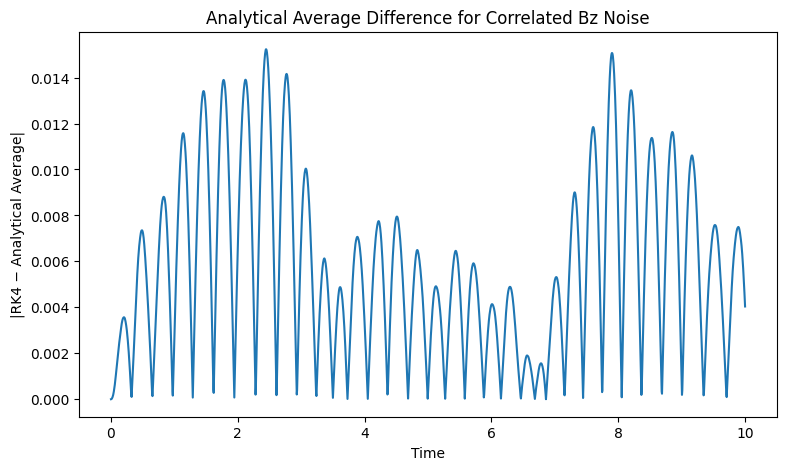

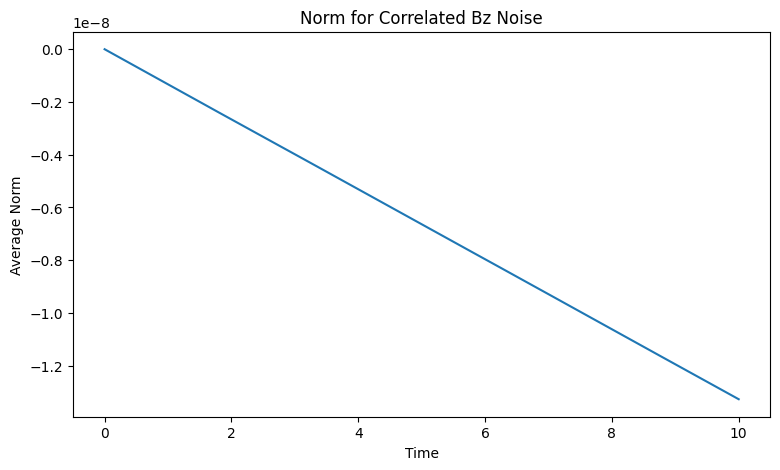

In [90]:
#Plots the numerical error between the RK4 result and analytical average.
plt.figure(figsize=(9, 5))
plt.plot(timeListExactCorrelated, rk4AnalyticalDifferenceCorrelated)
plt.title("Analytical Average Difference for Correlated Bz Noise")
plt.xlabel("Time")
plt.ylabel("|RK4 − Analytical Average|")
plt.show()

#Plots the average normalization error during the RK4 simulation.
plt.figure(figsize=(9, 5))
plt.plot(timeListRK4Correlated, normListRK4Correlated)
plt.title("Norm for Correlated Bz Noise")
plt.xlabel("Time")
plt.ylabel("Average Norm")
plt.show()

<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
/var/folders/bd/qwfmw3rd60j1xnj_h559_v140000gn/T/ipykernel_29620/4181131554.py:64: SyntaxWarning: invalid escape sequence '\p'
  '''plt.text((periodStart+periodEnd)/2, periodY+0.08, rf"$T=\pi/B_0={fringePeriod:.3f}$", color="green", fontsize=12, ha="center")'''


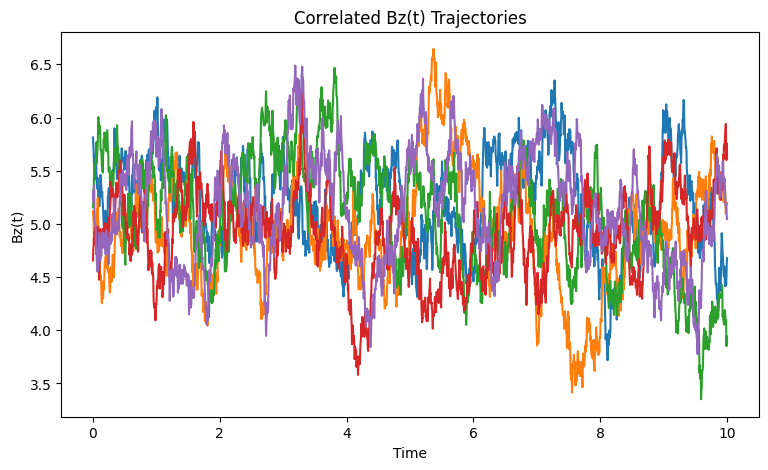

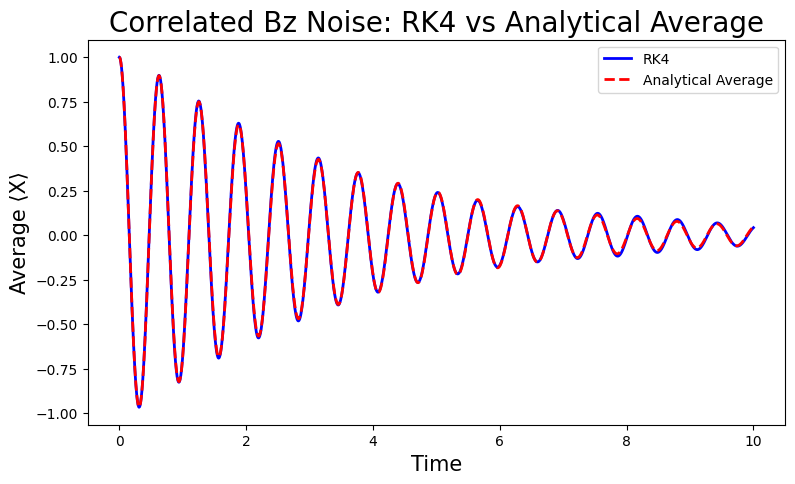

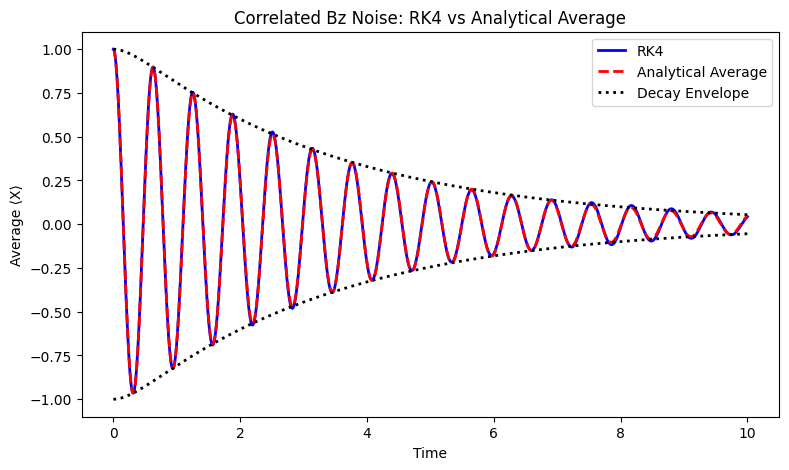

In [91]:
#Regenerates the correlated magnetic-field trajectories using the same random seed.
np.random.seed(1)
BzDataCorrelated = generateCorrelatedBzData(B0, sigma, tau, numTrials, deltat, tmax)

#Calculates the ensemble-averaged evolution using the exact constant-field method.
BzListCorrelated, newTimeListCorrelated, newAlphaListCorrelated, newBetaListCorrelated, newXListCorrelated, newNormListCorrelated = npb.Bzaverages(alpha0, beta0, Bx, By, BzDataCorrelated, deltat, tmax, 4)

#Plots five example correlated Bz trajectories.
plt.figure(figsize=(9, 5))
timeList = np.arange(len(BzDataCorrelated[0]))*deltat

for i in range(5):
    plt.plot(timeList, BzDataCorrelated[i])

plt.title("Correlated Bz(t) Trajectories")
plt.xlabel("Time")
plt.ylabel("Bz(t)")
plt.show()

#Calculates the noisy spin evolution using RK4 and the exact constant-field method.
BzListRK4Correlated, timeListRK4Correlated, alphaListRK4Correlated, betaListRK4Correlated, xListRK4Correlated, normListRK4Correlated = npb.Bzaverages(alpha0, beta0, Bx, By, BzDataCorrelated, deltat, tmax, 3)
BzListExactCorrelated, timeListExactCorrelated, alphaListExactCorrelated, betaListExactCorrelated, xListExactCorrelated, normListExactCorrelated = npb.Bzaverages(alpha0, beta0, Bx, By, BzDataCorrelated, deltat, tmax, 4)

#Calculates the analytical average X expectation value.
expectedXListCorrelated = expectedAverageXCorrelated(alpha0, beta0, B0, sigma, tau, timeListExactCorrelated)

#Compares the RK4 simulation with the analytical result.
plt.figure(figsize=(9, 5))
plt.plot(timeListRK4Correlated, xListRK4Correlated, label="RK4", color="blue", linewidth=2)
#plt.plot(timeListExactCorrelated, xListExactCorrelated, linestyle="--", label="Exact")
plt.plot(timeListExactCorrelated, expectedXListCorrelated, linestyle="--", label="Analytical Average", color="red", linewidth=2)
plt.title("Correlated Bz Noise: RK4 vs Analytical Average", fontsize=20)
plt.xlabel("Time", fontsize=15)
plt.ylabel("Average ⟨X⟩", fontsize=15)
plt.legend()
plt.show()

#Calculates the difference between RK4 and the analytical result.
xListRK4Correlated = np.array(xListRK4Correlated)
xListExactCorrelated = np.array(xListExactCorrelated)
rk4AnalyticalDifferenceCorrelated = np.abs(xListRK4Correlated-expectedXListCorrelated)

#Calculates the analytical dephasing envelope.
timeEnvelope = np.array(timeListExactCorrelated)
initialAmplitude = 2*np.abs(np.conjugate(alpha0)*beta0)
phaseVariance = 2*sigma**2*(tau*timeEnvelope-tau**2*(1-np.exp(-timeEnvelope/tau)))
decayEnvelope = initialAmplitude*np.exp(-2*phaseVariance)

#Calculates the expected oscillation period produced by the constant magnetic field B0.
fringePeriod = np.pi/B0
periodStart = 0.0
periodEnd = fringePeriod
periodY = 0.72

#Plots the RK4 result, analytical result, and positive and negative dephasing envelopes together.
plt.figure(figsize=(9, 5))
plt.plot(timeListRK4Correlated, xListRK4Correlated, label="RK4", color="blue", linewidth=2)
plt.plot(timeListExactCorrelated, expectedXListCorrelated, linestyle="--", label="Analytical Average", color="red", linewidth=2)
plt.plot(timeEnvelope, decayEnvelope, linestyle=":", color="black", linewidth=2, label="Decay Envelope")
plt.plot(timeEnvelope, -decayEnvelope, linestyle=":", color="black", linewidth=2)

'''plt.annotate("", xy=(periodEnd, periodY), xytext=(periodStart, periodY), arrowprops=dict(arrowstyle="<->", color="green", linewidth=2))'''

'''plt.text((periodStart+periodEnd)/2, periodY+0.08, rf"$T=\pi/B_0={fringePeriod:.3f}$", color="green", fontsize=12, ha="center")'''

plt.title("Correlated Bz Noise: RK4 vs Analytical Average")
plt.xlabel("Time")
plt.ylabel("Average ⟨X⟩")
plt.ylim(-1.1, 1.1)
plt.legend()
plt.show()

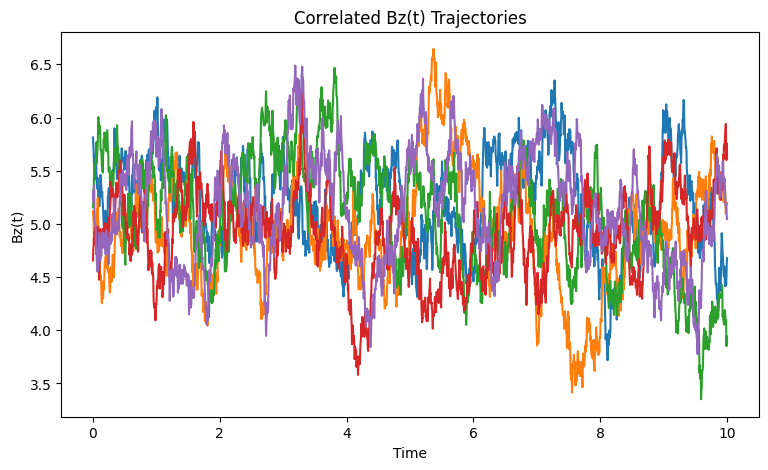

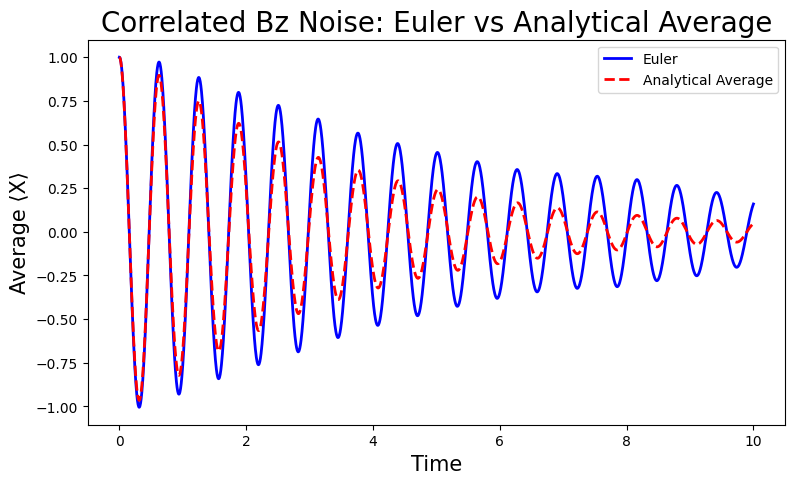

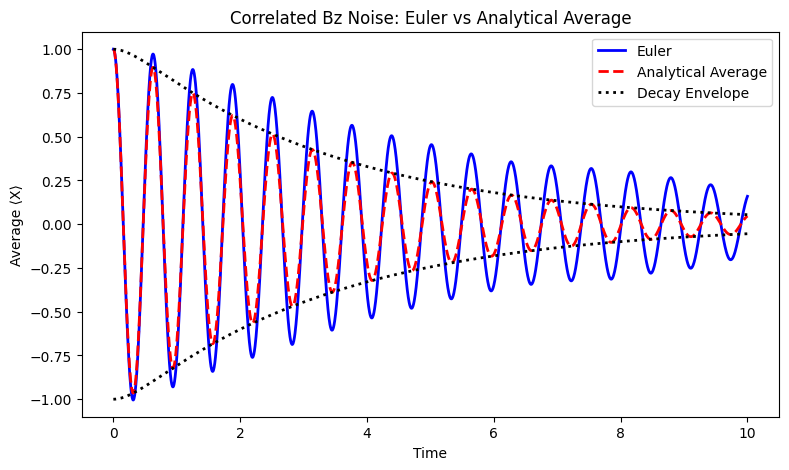

In [92]:
#Regenerates the same correlated noise trajectories using the same random seed.
np.random.seed(1)
BzDataCorrelated = generateCorrelatedBzData(B0, sigma, tau, numTrials, deltat, tmax)

#Calculates the ensemble-averaged spin evolution using the exact constant-field method.
BzListCorrelated, newTimeListCorrelated, newAlphaListCorrelated, newBetaListCorrelated, newXListCorrelated, newNormListCorrelated = npb.Bzaverages(alpha0, beta0, Bx, By, BzDataCorrelated, deltat, tmax, 4)

#Plots five example correlated magnetic-field trajectories.
plt.figure(figsize=(9, 5))
timeList = np.arange(len(BzDataCorrelated[0]))*deltat

for i in range(5):
    plt.plot(timeList, BzDataCorrelated[i])

plt.title("Correlated Bz(t) Trajectories")
plt.xlabel("Time")
plt.ylabel("Bz(t)")
plt.show()

#Calculates the noisy spin evolution using Euler's method.
BzListEulerCorrelated, timeListEulerCorrelated, alphaListEulerCorrelated, betaListEulerCorrelated, xListEulerCorrelated, normListEulerCorrelated = npb.Bzaverages(alpha0, beta0, Bx, By, BzDataCorrelated, deltat, tmax, 1)

#Calculates the exact constant-field evolution for comparison.
BzListExactCorrelated, timeListExactCorrelated, alphaListExactCorrelated, betaListExactCorrelated, xListExactCorrelated, normListExactCorrelated = npb.Bzaverages(alpha0, beta0, Bx, By, BzDataCorrelated, deltat, tmax, 4)

#Calculates the analytical ensemble-average X expectation value.
expectedXListCorrelated = expectedAverageXCorrelated(alpha0, beta0, B0, sigma, tau, timeListExactCorrelated)

#Compares Euler's numerical result with the analytical prediction.
plt.figure(figsize=(9, 5))
plt.plot(timeListEulerCorrelated, xListEulerCorrelated, label="Euler", color="blue", linewidth=2)
plt.plot(timeListExactCorrelated, expectedXListCorrelated, linestyle="--", label="Analytical Average", color="red", linewidth=2)
plt.title("Correlated Bz Noise: Euler vs Analytical Average", fontsize=20)
plt.xlabel("Time", fontsize=15)
plt.ylabel("Average ⟨X⟩", fontsize=15)
plt.legend()
plt.show()

#Calculates the difference between Euler's method and the analytical result.
xListEulerCorrelated = np.array(xListEulerCorrelated)
eulerAnalyticalDifferenceCorrelated = np.abs(xListEulerCorrelated-expectedXListCorrelated)

#Calculates the analytical dephasing envelope.
timeEnvelope = np.array(timeListExactCorrelated)
initialAmplitude = 2*np.abs(np.conjugate(alpha0)*beta0)
phaseVariance = 2*sigma**2*(tau*timeEnvelope-tau**2*(1-np.exp(-timeEnvelope/tau)))
decayEnvelope = initialAmplitude*np.exp(-2*phaseVariance)

#Calculates the oscillation period caused by the constant field B0.
fringePeriod = np.pi/B0
periodStart = 0.0
periodEnd = fringePeriod
periodY = 0.72

#Plots Euler's result, the analytical prediction, and the dephasing envelope.
plt.figure(figsize=(9, 5))
plt.plot(timeListEulerCorrelated, xListEulerCorrelated, label="Euler", color="blue", linewidth=2)
plt.plot(timeListExactCorrelated, expectedXListCorrelated, linestyle="--", label="Analytical Average", color="red", linewidth=2)
plt.plot(timeEnvelope, decayEnvelope, linestyle=":", color="black", linewidth=2, label="Decay Envelope")
plt.plot(timeEnvelope, -decayEnvelope, linestyle=":", color="black", linewidth=2)


plt.title("Correlated Bz Noise: Euler vs Analytical Average")
plt.xlabel("Time")
plt.ylabel("Average ⟨X⟩")
plt.ylim(-1.1, 1.1)
plt.legend()
plt.show()

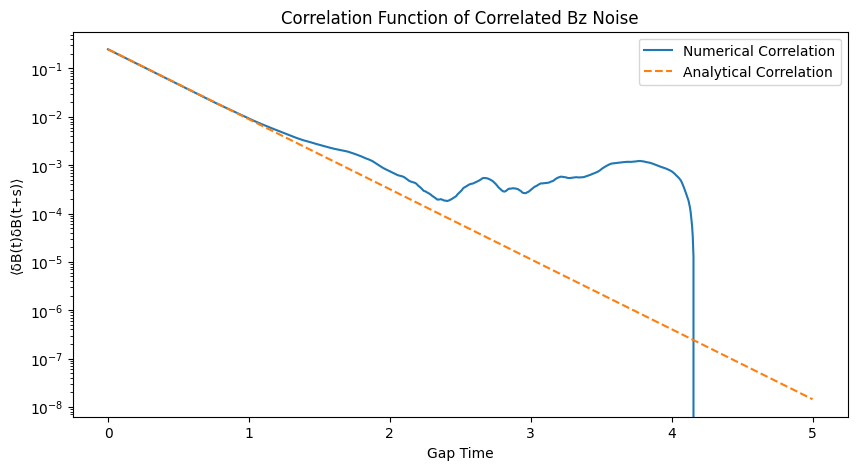

In [93]:
#Calculates both the numerical and analytical temporal correlation functions up to the chosen maximum lag time.
lagTime = 5.0
lagTimeList, numericalCorrelationList = numericalNoiseCorrelation(BzDataCorrelated, B0, deltat, lagTime)
analyticalCorrelationList = analyticalNoiseCorrelation(sigma, tau, lagTimeList)

#Compares the correlation measured from the generated noise with the expected exponential correlation function.
plt.figure(figsize=(10, 5))
plt.plot(lagTimeList, numericalCorrelationList, label="Numerical Correlation")
plt.plot(lagTimeList, analyticalCorrelationList, linestyle="--", label="Analytical Correlation")
plt.title("Correlation Function of Correlated Bz Noise")
plt.xlabel("Gap Time")
plt.ylabel("⟨δB(t)δB(t+s)⟩")
plt.yscale("log")
plt.legend()
plt.show()

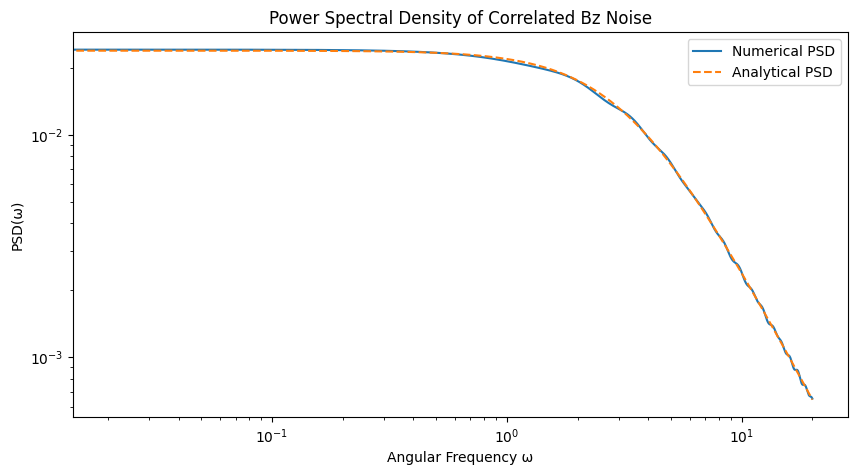

In [94]:
#Defines the frequency range and calculates both the numerical and analytical power spectral densities.
maxOmega = 20.0
omegaStep = 0.02
omegaList, numericalPSDList = numericalPSD(lagTimeList, numericalCorrelationList, maxOmega, omegaStep)
omegaList, analyticalPSDList = analyticalPSD(sigma, tau, maxOmega, omegaStep)

#Compares the PSD obtained from the numerical correlation function with the analytical Lorentzian PSD.
plt.figure(figsize=(10, 5))
plt.plot(omegaList, numericalPSDList, label="Numerical PSD")
plt.plot(omegaList, analyticalPSDList, linestyle="--", label="Analytical PSD")
plt.title("Power Spectral Density of Correlated Bz Noise")
plt.xlabel("Angular Frequency ω")
plt.ylabel("PSD(ω)")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()